<a href="https://colab.research.google.com/github/samyzaf/notebooks/blob/main/quadcopter_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Quadcopter Programming Project**
<small>version: 30.04.26b</small>

* Most of the text in this notebook was extracted by queries to AI agents
  like ChatGPT, Gemini, Grok, and Claude, from public web documents.
  Our main contribution is mainly for
  * Supplying the AI tools a large bulk of documents to parse and process
    (academic research papers, theses, summaries, YouTube PodCasts, etc.).
    These are listed in the references section at the end of this notebook.
  * In some cases, we had to convert some PDF documents to a more "AI digestible" formats
    so that AI tools could do better mining job on them.
    We used Python tools like [PyMuPDF](https://pymupdf.readthedocs.io/en/latest)
    and
    [PDFMiner](https://pypi.org/project/pdfminer).
  * Forming correct queries ("AI prompts"), directing, and asking the AI tools the "right" questions.
  * Organizing, paraphrasing, and filtering out redundant or duplicate materials.
  * Adding some more explanations in places where the AI answers were too short or cryptic.
* We are very thankful to all the authors of these documents (see references), and to all
  the software companies which developed the above AI agents,
  and made the documenting and coding tasks much easier (and fun) than before!
* The students are also encouraged to use these tools for unraveling and expanding on this
  notebook texts.
  Google Gemini is hardwired to Google Colab notebook and can be used
  for explaining the text, Physics, and Math.

* Thanks to Dr. Daniel Rabayev (Technion) for proposing the quadcopter programming project idea
  for an ODE Technion course,
  and for the references to the initial academic papers for building it.

* Thanks a lot to Yair Zafrany for AI mining ChatGPT and Claude for code, text, and diagrams.
  His long experience with working on a drone project has helped us a lot in the design of this
  notebook.

* Our main academic sources are located in:
  * https://samyzaf.com/quad/docs
  * https://samyzaf.com/quad/exercises


## **Introduction**
* Building a quadcopter simulation in a Google Colab notebook
  is a fantastic way to blend physics, math, coding, control theory,
  and make a great topic for an ordinary differential equations (ODE) course.

* Modeling and simulating a quadcopter can be done by a linear 12x12 system of ordinary
  differential equations (ODE).
  This topic is usually studied in an undergraduate course of engineering mathematics,
  usually at the end of the course, so you have enough time to study the theoretical background
  before attempting the computational tasks.

* The closest relative of the quadcopter is the single rotor helicopter,
  but the quadcopter has 4 rotors, and in most cases, is much smaller in size,
  much cheaper, and have much more versatile uses.

  <IMG src="https://samyzaf.com/quad/figs/qh1.jpg" width=70% align="center"/>

* A quadcopter is one type of the **Unmanned Aerial Vehicle (UAV)** category.

* To model a quadcopter, we treat it as a rigid body with six degrees
  of freedom (6 **DOF**):
  left, right, forward, backward, up, and down.

* All directions are driven by controlling four independent rotors.

* In most designs, the rotors are placed on 4 arms that extend from the center.

* There are several ways to attach a coordinate system to a quadcopter body.
  The usual design is as in this diagram:  

  <IMG src="https://samyzaf.com/quad/figs/qd0a.jpg" width=80% align="center"/>

* Every propeller with its rotor engine is placed at the end of each arm.

* In order to stabilize the quadcopter, two opposite propellers spin **clockwise**, and the
  other two must spin **counter clockwise**.

* When all the rotors rotate at the same angular speed (like $\omega_{hover}$),
  their torques are canceling each other out and the quadcopter
  will not spin around its Z-axis.

* By adjusting the 4 rotors speeds we can control the quadcopter movement in
  six different directions: left, right, forward, backward, up, and down.

* The dynamics of a quadcopter is understood by considering two reference frames:
  * Earth inertial frame `O` (see above figure)
  * Body fixed frame `B`.

* The **Earth Inertial Frame** (or **Earth Frame** for short)
  is a stationary **ground frame** which designates the quadcopter launch point.
  Its **positive Z-axis** is pointing to the sky and perpendicular to the earth ground.
  The **negative Z-axis** is always pointing to gravitational force direction (ground).

* In most mathematical and theoretical physics contexts,
  one of the arms is selected as a **front arm** and serves as the positive X-axis.
  The positive Y-axis is determined by the
  [right hand rule](https://en.wikipedia.org/wiki/Right-hand_rule)
  (see figure above, and see the `+` configuration discussion below).
  The motion of the quadcopter center of mass $(x,y,z)$ is always relative to this frame.

* The **body frame `B`** coordinates system is rooted at the quadcopter's center of mass
  and stretches along the arms of the quadcopter.
  This is a moving frame of course (which is tracked relative to the earth inertial frame).
  Its origin is the mass center $(x,y,z)$ of the quadcopter, where the point $(x,y,z)$
  belongs to the earth frame.

* There are three primary configurations for quadcopter body frame axis:
  * The `+` configuration
  * The `X` configuration
  * The `+` configuration with the front as the X-axis  

  <IMG src="https://samyzaf.com/quad/figs/quad_body_frames2.jpg" width=85% align="center"/>

* **The `+` Configuration** (body frame axis aligned with motor arms)
  is the most common configuration in theoretical papers and books
  where the Z-axis points upwards, the X-axis points along one arm
  (often the front arm) and the Y-axis points along another arm
  determined by the
  [right hand rule](https://en.wikipedia.org/wiki/Right-hand_rule).
  * To further simplify the math modeling,
    it is common to identify the positive X-axis as
    the front of the quadcopter:
    * **Rotor 1 (Front):** Rotates **Counter-Clockwise (CCW)**.
    * **Rotor 3 (Rear):** Rotates **Counter-Clockwise (CCW)**.
    * **Rotor 2 (Right):** Rotates **Clockwise (CW)**.
    * **Rotor 4 (Left):** Rotates **Clockwise (CW)**.
  * We call this configuration:
    **`+` configuration with the front as the X-axis**.
  * This alignment simplifies the mathematical modeling for several reasons:
    * **Direct Control Input Mapping:**
      In a `+` configuration, roll and pitch moments are directly generated by
      differential thrust from opposing pairs of motors along these aligned axes.
    * For example, roll is controlled by the difference in thrust between motors
      on the Y-axis, and pitch by motors on the X-axis.
    * This makes control allocation very straightforward,
      and simplified Dynamic Equations.
      Aligning the body frame with the arms simplifies the inertia terms
      in the equations of motion (like Euler-Lagrange or Newton-Euler).
    * For a symmetrically built quadcopter, the moments of inertia are most simply
      defined along these axes.
    * **Standard for Euler Angles:**
      The Euler angles (roll, pitch, yaw) correspond more naturally to rotations around
      these body axes, simplifying kinematic and dynamic relationships.

* **The `X` Configuration** (Body Frame Aligned with Front/Back and Sides)
  In an `X` configuration, the rotors are at the 'corners' of a square or rectangle,
  and the 'front' of the quadcopter points between two arms.
  For such a quadcopter, the body frame axes are often defined to align with
  this 'visual' front. Here's how it's typically done:
  * X-axis: The positive X-axis is aligned with the forward direction of the quadcopter
    (pointing directly out from the 'nose' between the two front arms).
  * Y-axis: The positive Y-axis is aligned with the leftward direction of the quadcopter
    (pointing directly out from the left side, between the two left arms).
  * Z-axis: The positive Z-axis still points upwards from the center of the quadcopter.

* However, for more practical real world simulations, engineering design, and advanced control,
  the body frame would indeed align with the `X` configuration's front, back,
  and sides, as described in the figure.

* Since our goal in this notebook is to show how the mathematical theory of
  ordinary difference equations is applied for quadcopter control and analysis,
  we preferred the `+` configuration with the X-axis front.

* Different papers may differ with rotor spin direction,
  but this difference has a minor impact on the differential equations
  (mostly trivial sign changes or coefficients), so it shouldn't really matter to us.

* In addition to spatial movement, we can also control 3 different body rotation modes:
  * **Roll $\phi$:** Rotation angle around the X-axis
  * **Pitch $\theta$:** Rotation angle around the Y-axis
  * **Yaw $\psi$:** Rotation angle around the Z-axis

* The angles $\phi$, $\theta$, and $\psi$ are called **Euler angles**.
  Positive values represent **counter clockwise direction (CCW)**.
  Negative values represent **clockwise direction (CW)**.

* By combining the mass center $(x,y,z)$ (in earth frame axis)
  with the Euler angles $(\phi,\theta,\psi)$ (in body frame axis),
  we are able to describe **all possible positions** of our quadcopter in **3D space**!  

  <IMG src="https://samyzaf.com/quad/figs/euler2.jpg" width=60% align="center"/>

* The mass center $(x,y,z)$ is always in the earth frame axis.

* The quadcopter motion in time $t$, is fully tracked by keeping record of
  its mass center 3D time (`t`) parametric curve $(x(t),y(t),z(t))$
  and the 3 Euler angles $(\phi(t),\theta(t),\psi(t))$
  which denote the deviation of the body axes with respect to the earth axes.  
  The time variable `t` is usually ranging over a closed interval `(t_start, t_end)`.

* The movement laws of a quadcopter are governed by Newton-Euler equations
  (or Euler-Lagrange equations).
  We track the position $(x,y,z)$ and the Euler angles $(\phi,\theta,\psi)$
  representing roll, pitch, and yaw.

* The quadcopter state vector usually includes 12 variables:  

  $\qquad x(t),y(t),z(t) \ ;\  x'(t),y'(t),z'(t) \ ; \  \phi(t),\theta(t),\psi(t) \ ;\  p(t), q(t), r(t)$  

  which will be explained in depth later on.

## **Translational and Rotational Dynamics**
* In the following discussion, we illustrate quadcopter movement maneuvering
  by controlling rotors speed levels.
  This should give us ground feeling and intuition before we dive
  into the physics and math modeling.
  * For illustration, we use 3 types of speeds:
    * $\omega_{up}$ - rotor speed for going up (thin arrow line)
    * $\omega_{hover}$ - rotor speed for hovering (medium arrow line)
    * $\omega_{down}$ - rotor speed for going down (thick arrow line)  

  <figure>
  <IMG src="https://samyzaf.com/quad/figs/quad_speeds1.jpg" width=40% align="center"/>
  </figure>  

  The $\omega_{hover}$ has a fixed value,
  but the $\omega_{up}$ can be any value larger than $\omega_{hover}$
  (which is supported by the rotor hardware),
  and $\omega_{down}$ can be any value smaller than $\omega_{hover}$.

* As noted above, we use the **`+` configuration** with the X-axis front.
  The rotors rotation direction on the Y-axis is positive (counter-clockwise),
  and the rotors direction on the X-axis is negative (clockwise).

  * **Nevertheless, we should emphasize that our main concern here is with the
    system of ordinary linear differential equations, in the context of an ODE course.
    So mastering the Physics dynamics intuitions is not required for doing the project,
    but it can help understand the equations.**

<!--
<figure>
<IMG src="https://samyzaf.com/quad/figs/quads2.jpg" width=100% align="center"/>
<figcaption>
Quadcopter movement maneuvering by controlling rotors speed levels  
<BR>
Notice the 3 different types of speed.
</figcaption>
</figure>
-->

* This setup allows the quadcopter to perform all six degrees of freedom
  by varying the speed of individual rotors:

* **Hovering:**
  Keep speed of all rotors equally to $\omega_{hover}$.  

* **Going down:**
  Decrease speed of all rotors equally.

* **Going up:**
  Increase speed of all rotors equally.  
       
  <IMG src="https://samyzaf.com/quad/figs/quads2a.jpg" width=80% align="center"/>

* **Positive Roll (X-axis rotation, counter-clockwise):**
  * Increase speed of rotor 4
  * Decrease speed of rotor 2
  * Keep rotors 1 and 3 on hover speed.  

* **Negative Roll (X-axis rotation, clockwise):**
  * Increase speed of rotor 2
  * Decrease speed of rotor 4
  * Keep rotors 1 and 3 on hover speed.  
      
  <IMG src="https://samyzaf.com/quad/figs/quads2b.jpg" width=75% align="center"/>

* **Positive Pitch (Y-axis rotation, counter-clockwise):**
  * Increase speed of rotor 3
  * Decrease speed of rotor 1
  * Keep rotors 2 and 4 on hover speed.  

* **Negative Pitch (Y-axis rotation, clockwise):**
  * Increase speed of rotor 1
  * Decrease speed of rotor 3
  * Keep rotors 2 and 4 on hover speed.  
      
  <IMG src="https://samyzaf.com/quad/figs/quads2c.jpg" width=75% align="center"/>

* **Positive Yaw (Z-axis rotation, counter-clockwise):**
  * Increase speed of rotors 3
  * Decrease speed of rotors 1

* **Negative Yaw (Z-axis rotation, clockwise):**
  * Increase speed of rotors 2, 4
  * Decrease speed of rotors 1, 3
      
  <IMG src="https://samyzaf.com/quad/figs/quads2d.jpg" width=75% align="center"/>

* Moving in other directions is achieved by similar combinations of rotors speeds.
  Since this is not our issue here, we will give one more example only.
  To move in a diagonal XY-direction we will need to
  * Increase speed of rotors 2, 3
  * Decrease speed of rotors 1, 4
    
  <IMG src="https://samyzaf.com/quad/figs/quad_move_xy.jpg" width=40% align="center"/>
    

* The dynamic model is derived using Euler-Lagrange formalism under the following assumptions:
  * The structure is supposed to be rigid.
  * The structure is supposed symmetrical.
  * The center of mass and the body fixed frame origin are assumed to coincide.

* The propellers are supposed rigid.
  * That means that propellers (rotors) cannon tilt with respect to body frame.

  * In more advanced models, the propellers may have a freedom to tilt within some
    angles ranges, which gives the quadcopter the ability to move in more ways than a standard quadcopter
    (like hovering in non-horizontal state, or moving in horizontal state).  

    <IMG src="https://samyzaf.com/quad/figs/qc10a.jpg" width=80% align="center"/>

  * These type of quadcopters are much harder to model mathematically
    and will not be discussed in this notebook.

  * Examples of this quadcopter type are discussed in
    [This paper](https://www.researchgate.net/publication/310327397_Design_Fabrication_and_Control_of_a_Tilt_Rotor_Quadcopter)
    from which we copied this diagram.

* The thrust and drag are proportional to the square of the propeller speed.

* Here is a breakdown of how to structure your project using Python's
  [scipy.integrate](https://docs.scipy.org/doc/scipy/reference)
  and
  [Numpy](https://numpy.org/doc/stable/reference).

## **Physics/Math Modeling**
* Next, we dive into the Physic/Math modeling of the translational
  and rotational dynamics of the quadcopter.
* We will use Newton laws and Euler's equations for rigid bodies.
* This will include defining the inertia tensor, the angular velocity
  vector in the body frame, and the torque vector, and showing how these
  relate to the angular accelerations.

### **Forces Acting on the Quadcopter**

Two primary forces govern the translational dynamics of the quadcopter:

* **Gravity ($F_g$):**
  * Gravity is a constant force acting vertically downwards, always aligned with
    the **negative Z-axis of the earth frame**.
    * Its magnitude is the product of the quadcopter's mass ($m$)
      and the acceleration due to gravity ($g$).
    * In the earth frame, the gravity vector is: $F_g = \begin{bmatrix} 0 \\ 0 \\ -mg \end{bmatrix}$

* **Total Thrust ($F_T$ or $T$):**
  * Thrust is the upward force generated by the quadcopter's propellers.
  It's the primary force that counteracts gravity and allows for vertical movement.
    * Crucially, the thrust always acts along the quadcopter's **body Z-axis** (its "up" direction).
    * The total thrust magnitude ($T$) is the sum of the thrust generated by each individual rotor.
    * In the body frame, the thrust vector is: $F_{thrust, body} = \begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix}$
    * Where $T = k(\omega_1^2 + \omega_2^2 + \omega_3^2 + \omega_4^2)$ and $k$
  is a thrust coefficient, and $\omega_i$ are the angular velocities of the rotors.
  (Note: For this derivation, we will simply use $T$ as the total thrust magnitude).

### **Rotation Matrix (Body Frame to earth Frame)**

* To transform forces and torques from the body frame (where they are naturally defined)
  to the earth frame (where Newton's laws are applied), we use a **Rotation Matrix** ($R$).
  This matrix essentially describes the quadcopter's orientation in space relative to the earth frame.

* As established in the introductory section, for quadcopters, the most common convention
  uses the ZYX Euler angle sequence:
  * First rotating around Yaw ($\psi$)
  * Then Pitch ($\theta$)
  * And finally Roll ($\phi$).

* The full rotation matrix $R$, which transforms a vector from the body frame
  to the earth frame, is the product of three individual rotation matrices:  
  $\qquad R = R_z(\psi) R_y(\theta) R_x(\phi)$  
  Where:
  * **Roll** ($\phi$) around the X-axis:  
  $\qquad
  R_x(\phi) =
  \begin{bmatrix}
  1 & 0 & 0 \\
  0 & \cos(\phi) & -\sin(\phi) \\
  0 & \sin(\phi) & \cos(\phi)
  \end{bmatrix}$
      
  * **Pitch** ($\theta$) around the Y-axis:  
  $\qquad
  R_y(\theta) =
  \begin{bmatrix}
  \cos(\theta) & 0 & \sin(\theta) \\
  0 & 1 & 0 \\
  -\sin(\theta) & 0 & \cos(\theta)
  \end{bmatrix}$
  
  * **Yaw** ($\psi$) around the Z-axis:  
  $\qquad
  R_z(\psi) =
  \begin{bmatrix}
  \cos(\psi) & -\sin(\psi) & 0 \\
  \sin(\psi) & \cos(\psi) & 0 \\
  0 & 0 & 1
  \end{bmatrix}$

* Multiplying these matrices in the specified order ($R_z(\psi) R_y(\theta) R_x(\phi)$)
  yields the complete rotation matrix $R$ (using $c$ for $\cos$ and $s$ for $\sin$):  
  $\qquad
  R = \begin{bmatrix}
  c(\psi)c(\theta) & c(\psi)s(\theta)s(\phi) -s(\psi)c(\phi) & c(\psi)s(\theta)c(\phi) + s(\psi)s(\phi) \\
  s(\psi)c(\theta) & s(\psi)s(\theta)s(\phi) + c(\psi)c(\phi)  & s(\psi)s(\theta)c(\phi) - c(\psi)s(\phi) \\
  -s(\theta) & c(\theta)s(\phi) & c(\theta)c(\phi)
  \end{bmatrix}$

### **Exercise 1: Python implementation of $R$.**
In Python, using
[Numpy](https://numpy.org/doc/stable/reference),
define this matrix efficiently to be used in your ODE solver.  
Your function should get 3 arguments:
the 3 Euler angles $\phi$, $\theta$, and $\psi$,
and return the matrix $R$.

**Solution:**
```python
def get_rotation_matrix(phi, theta, psi):
    # Pre-calculate cos and sin
    cp, sp = np.cos(phi), np.sin(phi)
    ct, st = np.cos(theta), np.sin(theta)
    cy, sy = np.cos(psi), np.sin(psi)
    
    R = np.array([
        [cy*ct, cy*st*sp - sy*cp, cy*st*cp + sy*sp],
        [sy*ct, sy*st*sp + cy*cp, sy*st*cp - cy*sp],
        [-st,   ct*sp,            ct*cp           ]
    ])
    return R
```

### **Transforming Thrust to the Earth Frame**
* Now we apply the rotation matrix $R$ to transform the thrust vector,
  which is defined in the body frame, into the earth frame.
  This is crucial because all external forces must be in the
  same coordinate system to be summed up.

* We have the thrust vector in the body frame as:
  $F_{thrust,body} =
  \begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix}$
  
  And the rotation matrix $R$ (body to earth):
  
  $R = \begin{bmatrix}
    c(\psi)c(\theta) & c(\psi)s(\theta)s(\phi) -s(\psi)c(\phi) & c(\psi)s(\theta)c(\phi) + s(\psi)s(\phi) \\
    s(\psi)c(\theta) & s(\psi)s(\theta)s(\phi) + c(\psi)c(\phi)  & s(\psi)s(\theta)c(\phi) - c(\psi)s(\phi) \\
    -s(\theta) & c(\theta)s(\phi) & c(\theta)c(\phi)
  \end{bmatrix}$
  
* To get the thrust in the earth frame
  ($F_{thrust, earth}$), we multiply $R$ by $F_{thrust, body}$:
  
  $F_{thrust, earth} = R \cdot F_{thrust, body} = \begin{bmatrix}
    c(\psi)c(\theta) & c(\psi)s(\theta)s(\phi) -s(\psi)c(\phi) & c(\psi)s(\theta)c(\phi) + s(\psi)s(\phi) \\
    s(\psi)c(\theta) & s(\psi)s(\theta)s(\phi) + c(\psi)c(\phi)  & s(\psi)s(\theta)c(\phi) - c(\psi)s(\phi) \\
    -s(\theta) & c(\theta)s(\phi) & c(\theta)c(\phi)
  \end{bmatrix} \begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix}$
  
* Performing the matrix multiplication, we note that only the third column of $R$
  is multiplied by $T$, as the other components of $F_{thrust, body}$ are zero:
  
  $F_{thrust, earth} = \begin{bmatrix}
    (c(\psi)s(\theta)c(\phi) + s(\psi)s(\phi)) T \\
    (s(\psi)s(\theta)c(\phi) - c(\psi)s(\phi)) T \\
    (c(\theta)c(\phi)) T
  \end{bmatrix}$
  
* This vector shows how the total thrust $T$, originally pointing along
  the body's Z-axis, is distributed among the X, Y, and Z axes of the earth frame
  based on the quadcopter's current roll ($\phi$), pitch ($\theta$), and yaw ($\psi$) angles.
  * The first component: $F_{thrust, earth, x} = (c(\psi)s(\theta)c(\phi) + s(\psi)s(\phi)) T$,  
    represents the thrust component acting along the earth X-axis.
  * The second component: $F_{thrust, earth, y} = (s(\psi)s(\theta)c(\phi) - c(\psi)s(\phi)) T$,  
    represents the thrust component acting along the earth Y-axis.
  * The third component: $F_{thrust, earth, z} = (c(\theta)c(\phi)) T$,  
    represents the thrust component acting along the earth Z-axis (vertical direction).
* As noted previously, `az = (thrust/m) * (np.cos(theta)*np.cos(phi)) - g`
  in simplified simulations essentially uses the third component divided by mass,
  which is `(c(theta)c(phi))T/m`,
  as the primary vertical acceleration component from thrust.

### **Net Force Calculation**
* With both the thrust and gravity forces expressed in the earth frame,
  we can now sum them to find the total net force ($F_{net}$) acting on
  the quadcopter.

* This net force will dictate the quadcopter's linear acceleration according to Newton's Second Law.
  We have:
  
  * Gravity in the earth frame:  
  $\qquad F_g = \begin{bmatrix} 0 \\ 0 \\ -mg \end{bmatrix}$
  
  * Thrust in the earth frame:  
  $\qquad F_{thrust, earth} =
  \begin{bmatrix}
  (\cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi)) T \\
  (\sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi)) T \\
  (\cos(\theta)\cos(\phi)) T
  \end{bmatrix}$
  
* Combining these, the net force in the earth frame is:
  
  $\qquad F_{net} = F_{thrust, earth} + F_g$
  
  $\qquad F_{net} = \begin{bmatrix}
  (\cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi)) T \\
  (\sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi)) T \\
  (\cos(\theta)\cos(\phi)) T - mg
  \end{bmatrix}$
  
* This vector represents the total force exerted on the quadcopter in the X, Y, and Z
  directions of the earth (world) frame.
  Each component of this vector will contribute to the acceleration along its respective axis.

### **Translational Accelerations**
* Newton's Second Law states that the net force acting on an object is equal to
  the product of its mass and acceleration ($F = ma$).
  Applying this to our quadcopter's translational dynamics, we can find the linear
  accelerations along the X, Y, and Z axes in the earth frame.
  
* From the previous step, we have the net force vector:
  
  $F_{net} = \begin{bmatrix}
    F_{net, x} \\
    F_{net, y} \\
    F_{net, z}
  \end{bmatrix} = \begin{bmatrix}
    (\cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi)) T \\
    (\sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi)) T \\
    (\cos(\theta)\cos(\phi)) T - mg
  \end{bmatrix}$
  
* According to Newton's Second Law, the acceleration vector
  $\vec{a} = \begin{bmatrix} \ddot{x} \\ \ddot{y} \\ \ddot{z} \end{bmatrix}$
  is given by $\vec{a} = \frac{1}{m} F_{net}$.
  
* Therefore, the linear accelerations are:
  * **Acceleration along the earth X-axis ($\ddot{x}$):**  

    $\qquad\ddot{x} = \frac{1}{m} F_{net, x} = \frac{T}{m} (\cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi))$
  
  * **Acceleration along the earth Y-axis ($\ddot{y}$):**  

    $\qquad\ddot{y} = \frac{1}{m} F_{net, y} = \frac{T}{m} (\sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi))$
  
  * **Acceleration along the earth Z-axis ($\ddot{z}$):**  

    $\qquad\ddot{z} = \frac{1}{m} F_{net, z} = \frac{T}{m} (\cos(\theta)\cos(\phi)) - g$
  
* These three equations describe how the quadcopter's linear acceleration changes over time
  based on the total thrust, its mass, gravity, and its current orientation.

### **First-Order ODEs for Position and Velocity**
* Before we can implement a software model,
  we need a good mathematical/physical model of a quadcopter.

* As defined earlier, we use two primary coordinate systems:
  * An **earth inertial frame**, also called **earth frame** (fixed to the earth launch point)
  * A **body frame** around the quadcopter's center of mass. See earlier description.

* The common mathematical model for the motion of a quadcopter are the **Newton-Euler equations**,
  which describe the relationship between rotor thrust/torques forces and the
  quadcopter's angular accelerations.

* **State Vector:**
  Typically includes 12 variables:
  * **Position** $(x(t), y(t), z(t))$ at time $t$.
  * **Linear Velocities**
    $\dot{x}$, $\dot{y}$, $\dot{z}$
    * This is the notation used in Physics for the derivatives $x'(t)$, $y'(t)$, $z'(t)$.
  * **Euler Angles** (roll $\phi$, pitch $\theta$, and yaw $\psi$).
    * **Roll** $\phi(t)$: Rotation around the X-axis at time $t$.   
    * **Pitch** $\theta(t)$: Rotation around the Y-axis at time $t$.  
    * **Yaw** $\psi(t)$: Rotation around the Z-axis.
  * **Angular rates** $(p(t), q(t), r(t))$.  
    Angular rates in the body frame: (roll rate $p$, pitch rate $q$, yaw rate $r$).
    These are always measured with respect to body frame.
    * Not to be confused with the Euler angles derivatives $\phi'(t)$, $\theta'(t)$, $\psi'(t)$!
    * For example, roll rate ($p(t)$) is the angular velocity around the
      quadcopter's body-fixed X-axis from the point of view of the body frame.
      A positive roll rate indicates a rotation that would cause the left side (positive Y-axis)
      of the quadcopter to move upwards and the right side to move downwards.
  * More information on these variables is provided below.

* To solve the translational dynamics numerically using an ODE solver like
  **[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)**,
  we need to express all dynamics as a system of
  first-order differential equations.
  The state vector for translational dynamics typically includes position and velocity components.
  
* Let the translational state vector be $\mathbf{X}_{trans} = [x, y, z, \dot{x}, \dot{y}, \dot{z}]^T$.
  
* The derivatives of these states are then:
  * **Rates of change of Position (which are the Linear Velocities):**
    * $\dot{x} = v_x$
    * $\dot{y} = v_y$
    * $\dot{z} = v_z$
  
  * **Rates of change of Velocity (which are the Linear Accelerations):**

    *   $\dot{v}_x = \ddot{x} = \frac{T}{m} (\cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi))$

    *   $\dot{v}_y = \ddot{y} = \frac{T}{m} (\sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi))$

    *   $\dot{v}_z = \ddot{z} = \frac{T}{m} (\cos(\theta)\cos(\phi)) - g$
  
* Combining these, the first-order ODEs for the translational dynamics are:
  
  $\frac{d}{dt} \begin{bmatrix} x \\ y \\ z \\ v_x \\ v_y \\ v_z \end{bmatrix} = \begin{bmatrix}
    v_x \\
    v_y \\
    v_z \\
    \frac{T}{m} (\cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi)) \\
    \frac{T}{m} (\sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi)) \\
    \frac{T}{m} (\cos(\theta)\cos(\phi)) - g
  \end{bmatrix}$
  
* This system of six first-order differential equations completely describes the translational
  motion of the quadcopter, given its mass, current orientation
  ($\phi, \theta, \psi$), and total thrust ($T$).
  These equations will be integrated over time to predict the quadcopter's position and linear velocity.

### **Detailed Rotational Dynamics**

* Elaborate on the rotational dynamics using Euler's equations for rigid bodies.
* This will include defining the inertia tensor, the angular velocity vector in the body frame,
  and the torque vector, and showing how these relate to the angular accelerations
  `(p_dot, q_dot, r_dot)`.

### **Defining the Inertia Tensor (I)**
* For a rigid body like a quadcopter, the **Inertia Tensor ($I$)** is a crucial 3x3 matrix
  that describes how its mass is distributed relative to its axis of rotation.
  It's the rotational equivalent of mass in translational motion,
  indicating the body's resistance to changes in its angular velocity.
  
* In its most general form, the inertia tensor about a coordinate system originating
  at the body's center of mass is:  

  $\qquad I = \begin{bmatrix}
  I_{xx} & I_{xy} & I_{xz} \\
  I_{yx} & I_{yy} & I_{yz} \\
  I_{zx} & I_{zy} & I_{zz}
  \end{bmatrix}$
  
  Where:
  * $I_{xx}, I_{yy}, I_{zz}$ are the **moments of inertia** about the x, y, and z axes, respectively.
    They represent the resistance to rotation about that specific axis.
  * $I_{xy}, I_{xz}, \dots$ are the **products of inertia**, which describe the mass distribution
    with respect to pairs of axes and cause coupling between rotations about different axes.
  
* For a quadcopter, which is typically designed with a high degree of symmetry
  (especially if the center of mass coincides with the body frame origin),
  the products of inertia are often assumed to be zero.
  This simplifies the inertia tensor to a diagonal matrix:  
  
  $\qquad I = \begin{bmatrix}
  I_{xx} & 0 & 0 \\
  0 & I_{yy} & 0 \\
  0 & 0 & I_{zz}
  \end{bmatrix}$
  
* This simplification is valid because the quadcopter's body axes are principal axes of inertia.
  In Python, this can be easily represented using
  [Numpy](https://numpy.org/doc/stable/reference),
  as `np.diag([Ixx, Iyy, Izz])`.
  This generates the above diagonal 3x3 matrix.

## **Defining the Angular Velocity Vector ($\omega$)**
* The **angular velocity vector (${\omega}$)** in the quadcopter's body frame
  describes the rate and direction of its rotation relative to its own axes.
  In the context of the body frame (x, y, z axes fixed to the quadcopter),
  this vector is typically represented by its components along these axes:  

$\qquad \omega =
\begin{bmatrix}
p \\
q \\
r
\end{bmatrix}$

  Where:
  * **$p$**: Represents the angular velocity around the body-fixed X-axis (roll rate).
  * **$q$**: Represents the angular velocity around the body-fixed Y-axis (pitch rate).
  * **$r$**: Represents the angular velocity around the body-fixed Z-axis (yaw rate).

* These components ($p, q, r$) are also known as the **body rates** or **angular rates**.
  They are fundamental to understanding the quadcopter's rotational motion and are part
  of the 12-state vector mentioned earlier.

## **Defining the Torque Vector ($\tau$)**
* The **torque vector ($\tau$)** represents the net rotational forces acting on
  the quadcopter's body about its center of mass.
  These torques cause the quadcopter to change its angular velocities
  (i.e., roll, pitch, and yaw rates).

* For a quadcopter, torques are primarily generated by differences in the thrust
  produced by individual rotors and aerodynamic drag effects.
  Each rotor produces a thrust force that acts some distance from
  the center of mass, creating a moment.

* Additionally, the spinning rotors themselves generate reaction torques
  (due to air resistance and motor friction) which contribute to yaw.

* The torque vector is typically defined in the body frame as:  

$\qquad \tau = \begin{bmatrix}
\tau_x \\
\tau_y \\
\tau_z
\end{bmatrix}$

  Where:
  * $\tau_x$ is the net torque about the body-fixed X-axis (causes roll).
  * $\tau_y$ is the net torque about the body-fixed Y-axis (causes pitch).
  * $\tau_z$ is the net torque about the body-fixed Z-axis (causes yaw).

### **How Torques are Generated (+ Configuration with X-axis Front)**
* As established earlier, we use the `+` configuration with the X-axis pointing forward.
  The rotors are numbered as follows:
  *   **Rotor 1 (Front):** Rotates **Counter-Clockwise (CCW)**.
  *   **Rotor 2 (Right):** Rotates **Clockwise (CW)**.
  *   **Rotor 3 (Rear):** Rotates **Counter-Clockwise (CCW)**.
  *   **Rotor 4 (Left):** Rotates **Clockwise (CW)**.

  <IMG src="https://samyzaf.com/quad/figs/quad_plain.jpg" width=40% align="center"/>

  Let $T_i = k \omega_i^2$ be the thrust generated by rotor $i$
  (where $k$ is the lift constant and $\omega_i$ is the angular speed of rotor $i$),
  and $D_i = b \omega_i^2$ be the drag torque generated by rotor $i$
  (where $b$ is the drag constant). The arm length from the center of mass to each rotor is $L$.

* **Roll Torque ($\tau_x$):** Generated by differential thrust between the left (Rotor 4) and
  right (Rotor 2) rotors. For a positive roll moment (rotation around +X axis, counter-clockwise from front view),
  we need more thrust on the left side and less on the right side.
  Therefore:  
  $\qquad \tau_x = L(T_4 - T_2)$

* **Pitch Torque ($\tau_y$):** Generated by differential thrust between the rear (Rotor 3) and
  front (Rotor 1) rotors. For a positive pitch moment (rotation around +Y axis, nose up),
  we need more thrust at the rear and less at the front.
  Therefore:  
  $\qquad \tau_y = L(T_3 - T_1)$

* **Yaw Torque ($\tau_z$):** Generated by the reaction torques (drag) from the propellers.
  Rotors spinning CCW (Rotor 1 & 3) create a CW reaction torque (negative yaw moment) on the body.
  Rotors spinning CW (Rotor 2 & 4) create a CCW reaction torque (positive yaw moment) on the body.
  Therefore:  
  $\qquad \tau_z = (D_2 + D_4 - D_1 - D_3)$

* These formulas illustrate how varying individual rotor speeds allows for
  precise control over the quadcopter's attitude.

### **Introduce Euler's Equations for Rigid Bodies**

* To describe the rotational motion of a rigid body, we use **Euler's Equations of Motion**.
  These equations relate the net external torque acting on a body to its angular
  acceleration, considering its mass distribution (inertia) and its current angular velocity.

* In the body-fixed frame, Euler's equations for rotational dynamics are given by:  

  $\qquad I \dot{\omega} + \omega \times (I \omega) = \tau $

  Let's break down each term:

* **$I \dot{\omega}$**: This term represents the **rate of change of angular momentum**
  if viewed from the body-fixed frame without considering the frame's rotation.
  $\dot{\omega}$ is the angular acceleration vector, whose components are
  $[\dot{p}, \dot{q}, \dot{r}]^T$.
  * $I$: The inertia tensor of the quadcopter.
  * $\dot{\omega}$: The angular acceleration vector, representing the rate of
  change of the angular velocity components $p, q, r$.

* **$\omega \times (I \omega)$**:
  This is the **gyroscopic term** or **precessional term**.
  It accounts for the apparent torques that arise because the angular momentum vector
  is observed from a rotating (body-fixed) frame.
  Even if the angular momentum $H = I \omega$ is constant in the earth frame,
  its representation in the rotating body frame will change if the body is rotating.
  This term captures those effects.
  It's the rotational analogue of the Coriolis force in translational dynamics.
  * $\omega$: The angular velocity vector of the body.
  * $I \omega$: The angular momentum vector of the body.
  * $\times$: Denotes the cross product.

* **$\tau$**:
  This is the **net external torque vector** acting on the quadcopter about its center of mass,
  as defined previously. It represents all torques from thrust differences,
  drag, and any other external rotational forces.

* This equation effectively states that the sum of the rate of change of angular momentum
  (as seen from the rotating body frame) and the gyroscopic effects equals
  the net external torque applied to the body.
  Solving this equation allows us to determine the angular accelerations
  (i.e., $\dot{p}, \dot{q}, \dot{r}$) of the quadcopter.

## **Deriving Angular Accelerations ($\dot{p}, \dot{q}, \dot{r}$)**

* Now, let's expand Euler's equations into their component form, assuming
  a diagonal inertia tensor $I = \text{diag}(I_{xx}, I_{yy}, I_{zz})$
  and expressing the angular velocity as
  $\omega = [p, q, r]^T$ and torque as $\tau = [\tau_x, \tau_y, \tau_z]^T$.

* The full Euler's equation is:
$I \dot{\omega} + \omega \times (I \omega) = \tau$.

* First, let's calculate the terms:

  1. **$I \dot{\omega}$**:  
  $\qquad
  I \dot{\omega} = \begin{bmatrix}
  I_{xx} & 0 & 0 \\
  0 & I_{yy} & 0 \\
  0 & 0 & I_{zz}
  \end{bmatrix} \begin{bmatrix}
  \dot{p} \\
  \dot{q} \\
  \dot{r}
  \end{bmatrix} = \begin{bmatrix}
  I_{xx}\dot{p} \\
  I_{yy}\dot{q} \\
  I_{zz}\dot{r}
  \end{bmatrix}$
  
  2. **$I \omega$**:
  $\qquad I \omega = \begin{bmatrix}
  I_{xx} & 0 & 0 \\
  0 & I_{yy} & 0 \\
  0 & 0 & I_{zz}
  \end{bmatrix} \begin{bmatrix}
  p \\
  q \\
  r
  \end{bmatrix} = \begin{bmatrix}
  I_{xx}p \\
  I_{yy}q \\
  I_{zz}r
  \end{bmatrix}$
  
  3. $\omega \times (I \omega)$:  
  $\qquad
  \omega \times (I \omega) = \begin{bmatrix}
  p \\
  q \\
  r
  \end{bmatrix} \times \begin{bmatrix}
  I_{xx}p \\
  I_{yy}q \\
  I_{zz}r
  \end{bmatrix} =
  \begin{bmatrix}
  q(I_{zz}r) - r(I_{yy}q) \\
  r(I_{xx}p) - p(I_{zz}r) \\
  p(I_{yy}q) - q(I_{xx}p)
  \end{bmatrix} = \begin{bmatrix}
  (I_{zz} - I_{yy})qr \\
  (I_{xx} - I_{zz})rp \\
  (I_{yy} - I_{xx})pq
  \end{bmatrix}$

* Now, substitute these back into Euler's equation
  $I \dot{\omega} + \omega \times (I \omega) = \tau$:   
  $\qquad \begin{bmatrix}
  I_{xx}\dot{p} \\
  I_{yy}\dot{q} \\
  I_{zz}\dot{r}
  \end{bmatrix} + \begin{bmatrix}
  (I_{zz} - I_{yy})qr \\
  (I_{xx} - I_{zz})rp \\
  (I_{yy} - I_{xx})pq
  \end{bmatrix} = \begin{bmatrix}
  \tau_x \\
  \tau_y \\
  \tau_z
  \end{bmatrix}$

* Rearranging to solve for the angular accelerations ($\dot{p}, \dot{q}, \dot{r}$):

* **For $\dot{p}$ (Roll Acceleration):**  
  $\qquad I_{xx}\dot{p} = \tau_x - (I_{zz} - I_{yy})qr$  
  Hence  
  $\qquad\dot{p} = \dfrac{\tau_x - (I_{zz} - I_{yy})qr}{I_{xx}}$

* **For $\dot{q}$ (Pitch Acceleration):**  
  $\qquad I_{yy}\dot{q} = \tau_y - (I_{xx} - I_{zz})rp$  
  Hence  
  $\qquad\dot{q} = \dfrac{\tau_y - (I_{xx} - I_{zz})rp}{I_{yy}} $

* **For $\dot{r}$ (Yaw Acceleration):**  
  $\qquad I_{zz}\dot{r} = \tau_z - (I_{yy} - I_{xx})pq$  
  Hence  
  $\qquad\dot{r} = \dfrac{\tau_z - (I_{yy} - I_{xx})pq}{I_{zz}} $

* These equations show how the angular accelerations (rates of change of p, q, r)
  depend on the applied torques ($\tau_x, \tau_y, \tau_z$), the current angular velocities
  ($p, q, r$), and the quadcopter's moments of inertia
  ($I_{xx}, I_{yy}, I_{zz}$).
  The terms like $(I_{zz} - I_{yy})qr$ represent the gyroscopic effects.

### **First-Order ODEs for Angular Rates**

* The derived angular accelerations $\dot{p}, \dot{q}, \dot{r}$ are precisely
  the first-order ordinary differential equations that describe the evolution
  of the quadcopter's angular rates over time.
  These equations are directly integrated by numerical solvers
  like
  **[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)**,
  to update the angular rate components of the state vector.

* To reiterate, the system of first-order ODEs for the angular rates
  (part of the 12-state model) is:

* **Roll Rate Derivative ($\dot{p}$):**
  $\qquad \dot{p} = \dfrac{\tau_x - (I_{zz} - I_{yy})qr}{I_{xx}} $

* **Pitch Rate Derivative ($\dot{q}$):**
  $\qquad \dot{q} = \dfrac{\tau_y - (I_{xx} - I_{zz})rp}{I_{yy}} $

* **Yaw Rate Derivative ($\dot{r}$):**
  $\qquad \dot{r} = \dfrac{\tau_z - (I_{yy} - I_{xx})pq}{I_{zz}} $

* These three equations, alongside the translational dynamics and
  the kinematic relationships for Euler angles (which will be covered next),
  form the complete set of differential equations required to simulate
  the quadcopter's 6-DOF motion.
  When implemented in the `physics_dynamics` function (see code below),
  these equations will provide the `dp`, `dq`, and `dr` values based on
  the current state and applied torques.

## **Kinematics: Euler Rates vs. Body Rates**

* We now explain the crucial kinematic relationship between the body-fixed angular
  velocities (p, q, r) and the rates of change of the Euler angles
  (phi_dot, theta_dot, psi_dot), providing the transformation matrix that connects
  these two sets of angular rates.

### **Introduction to Euler Angles and their Rates**

* To describe the orientation of the quadcopter in 3D space, we use **Euler angles**:
  roll ($\phi$), pitch ($\theta$), and yaw ($\psi$).
  These angles define a sequence of rotations from a fixed earth frame (world frame)
  to the quadcopter's body frame.

  * **Roll ($\phi$)**: Rotation about the body's X-axis.
  * **Pitch ($\theta$)**: Rotation about the body's Y-axis.
  * **Yaw ($\psi$)**: Rotation about the body's Z-axis.

* The rates of change of these angles are denoted as $\dot{\phi}$, $\dot{\theta}$,
  and $\dot{\psi}$. These represent how fast the quadcopter is changing its roll,
  pitch, and yaw *with respect to the earth frame*.
  It's important to understand that these rates are *not* directly
  the angular velocities measured by gyroscopes on the quadcopter.

### **Distinction: Euler Angle Rates vs. Body-Fixed Angular Velocities**
* It's crucial to distinguish between the rates of change of Euler angles
  ($\dot{\phi}$, $\dot{\theta}$, $\dot{\psi}$)
  and the body-fixed angular velocities ($p$, $q$, $r$):

* **Body-Fixed Angular Velocities ($p, q, r$)**:
  These are the components of the angular velocity vector of the quadcopter
  *expressed in its own body-fixed coordinate system*.
  They represent the instantaneous rotation rates about the body's X, Y,
  and Z axes, respectively.
  These are the values typically measured by on board gyroscopes.
  * $p$: Angular velocity about the body X-axis (roll rate).
  * $q$: Angular velocity about the body Y-axis (pitch rate).
  * $r$: Angular velocity about the body Z-axis (yaw rate).

* **Euler Angle Rates ($\dot{\phi}$, $\dot{\theta}$, $\dot{\psi}$)**:
  These are the rates of change of the angles that define the orientation.
  The key difference is that the axes of rotation for Euler angles are
  *not always fixed in the body frame*.
  For example, a rotation about pitch ($\theta$) changes the orientation
  of the axis for roll ($\phi$).
  This makes Euler angle rates conceptually different from body-fixed angular velocities.

* Imagine a spinning top: $p, q, r$ describe its instantaneous spin velocity components
  along its own axes. $\dot{\phi}$, $\dot{\theta}$, $\dot{\psi}$ describe how quickly
  its orientation angles are changing in the room it's in.

### **Transformation Matrix: Body-Fixed Angular Velocities to Euler Angle Rates**
*  There is a specific kinematic relationship that connects the body-fixed angular
   velocities ($p, q, r$) to the Euler angle rates ($\dot{\phi}$, $\dot{\theta}$,
   $\dot{\psi}$).
   This relationship is derived by considering the contributions of each Euler rate
   to the overall angular velocity in the body frame.

* The relationship from Euler rates to body rates is given by:  

$\qquad \begin{bmatrix} p \\ q \\ r \end{bmatrix} =
\begin{bmatrix} 1 & 0 & -\sin\theta \\ 0 & \cos\phi & \cos\theta \sin\phi \\ 0 & -\sin\phi & \cos\theta \cos\phi \end{bmatrix}
\begin{bmatrix} \dot{\phi} \\ \dot{\theta} \\ \dot{\psi} \end{bmatrix} \qquad (1)$

* However, for formulating ODEs where we need to find the rates of change of Euler angles
  given the body-fixed angular velocities (which we obtain from rotational dynamics),
  we need the inverse transformation:  

$\qquad \begin{bmatrix} \dot{\phi} \\ \dot{\theta} \\ \dot{\psi} \end{bmatrix} =
\mathbf{T} \begin{bmatrix} p \\ q \\ r \end{bmatrix} $

  Where $\mathbf{T}$ is the transformation matrix. Deriving this inverse,
  or more commonly just stating the standard result, we get:  

$\qquad \begin{bmatrix} \dot{\phi} \\ \dot{\theta} \\ \dot{\psi} \end{bmatrix} =
\begin{bmatrix} 1 & \sin\phi \tan\theta & \cos\phi \tan\theta \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi / \cos\theta & \cos\phi / \cos\theta \end{bmatrix}
\begin{bmatrix} p \\ q \\ r \end{bmatrix} \qquad (2)$

* This matrix $\mathbf{T}$ allows us to convert the angular velocities measured in
  the quadcopter's body frame ($p, q, r$) into the rates of change of the Euler angles
  ($\dot{\phi}$, $\dot{\theta}$, $\dot{\psi}$) that describe its overall orientation
  change in the world frame.

### **Explanation of the Singularity (Gimbal Lock)**
* An important consideration for the transformation matrix $\mathbf{T}$ is
  the presence of the term $\cos\theta$ in the denominator of the last row,
  and $\tan\theta = \sin\theta / \cos\theta$ in the first row.

* This implies a **singularity** when the pitch angle ($\theta$) approaches $\pm 90^\circ$.
  At these angles, $\cos\theta = 0$, and the terms involving $\tan\theta$ or division
  by $\cos\theta$ become undefined (go to infinity).

* This phenomenon is known as **Gimbal Lock**.
  When $\theta = \pm 90^\circ$, the rotation axis for roll ($\phi$) becomes aligned with
  the rotation axis for yaw ($\psi$).
  This results in a loss of one degree of rotational freedom, making it impossible
  to uniquely determine all three Euler angle rates from the body rates.
  Physically, the system can't distinguish between a roll rate and a yaw rate,
  as they effectively act around the same axis.

* **Implications for Quadcopter Modeling and Control:**
  * **Modeling Limitations:** Simulations using Euler angles can become numerically
    unstable or inaccurate when the quadcopter flies close to a pitch of $\pm 90^\circ$
    (e.g., vertical flight).
  * **Control Challenges:** A controller relying solely on Euler angles and their rates
    might struggle to maintain stable flight in these orientations.

* For systems that are expected to perform aggressive maneuvers or operate through a full
  range of attitudes, alternative orientation representations like **quaternions**
  are often preferred, as they are singularity-free.

### **Formulating First-Order ODEs for Euler Angles**
* From Equation (2), we can directly write the first-order ordinary differential
  equations for the rates of change of the Euler angles:

  * $\dot{\phi} = p + q \sin\phi \tan\theta + r \cos\phi \tan\theta$
  * $\dot{\theta} = q \cos\phi - r \sin\phi$
  * $\dot{\psi} = q \sin\phi / \cos\theta + r \cos\phi / \cos\theta$

* These three equations, along with the equations for translational dynamics
  ($\dot{x}, \dot{y}, \dot{z}, \dot{v}_x, \dot{v}_y, \dot{v}_z$) and rotational dynamics
  ($\dot{p}, \dot{q}, \dot{r}$), form the complete 12-state system of ODEs
  for the quadcopter model. In an ODE solver like,
  **[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)**,
  these equations will be used to update the Euler angles ($\phi, \theta, \psi$)
  at each time step based on the current body angular velocities
  ($p, q, r$) and current Euler angles.

### **Formulating the Complete 12-State ODE System**

* To fully capture the dynamics of a quadcopter, we combine the translational
  and rotational dynamics, along with the kinematic relationships between
  Euler angle rates and body angular velocities, into a single system of 12
  first-order ordinary differential equations.

#### **1. The 12-State Vector**
* The state of the quadcopter at any given time $t$ is represented by a 12-dimensional
  vector $\mathbf{X}(t)$:  

  $\qquad \mathbf{X}(t) = \begin{bmatrix}
    x \\ y \\ z \\ v_x \\ v_y \\ v_z \\ \phi \\ \theta \\ \psi \\ p \\ q \\ r
  \end{bmatrix}$

  Where:
  * $(x, y, z) = (x(t), y(t), z(t))$:
    Position of the center of mass in the earth (world) frame.
  * $(\dot{x}, \dot{y}, \dot{z}) = (v_x, v_y, v_z) = (x'(t), y'(t), z'(t))$:
    Linear velocities along the earth axes.
  * $(\phi, \theta, \psi) = (\phi(t), \theta(t), \psi(t))$:
    Euler angles (roll, pitch, yaw) representing the orientation of the quadcopter's
    body frame relative to the earth frame.
  * $(\dot{\phi}, \dot{\theta}, \dot{\psi}) = (\phi'(t), \theta'(t), \psi'(t))$:
    Euler angles derivatives representing the orientation change rate of the quadcopter's
    body frame relative to the earth frame.
  * $(p, q, r) = (p(t), q(t), r(t))$:
    Angular velocities (roll rate, pitch rate, yaw rate) in the body frame.

#### **2. The System of 12 First-Order ODEs**

* The derivative of the state vector, $\dot{\mathbf{X}}(t)$,
  is composed of the following equations:

  **Translational Dynamics (Position and Linear Velocity):**

  1. $\dot{x} = v_x$
  2. $\dot{y} = v_y$
  3. $\dot{z} = v_z$
  4. $\dot{v}_x = a_x \quad\text{ (Linear acceleration in earth X-direction)}$
  5. $\dot{v}_y = a_y \quad\text{ (Linear acceleration in earth Y-direction)}$
  6. $\dot{v}_z = a_z \quad\text{ (Linear acceleration in earth Z-direction)}$

* From Newton's Second Law,
  $m\mathbf{a} = R \begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix} -
  \begin{bmatrix} 0 \\ 0 \\ mg \end{bmatrix}$,
  where $\begin{bmatrix} a_x \\ a_y \\ a_z \end{bmatrix} =
  \frac{1}{m} \left( R \begin{bmatrix} 0 \\ 0 \\ T \end{bmatrix} -
  \begin{bmatrix} 0 \\ 0 \\ mg \end{bmatrix} \right)$.

**Kinematic Relationships (Euler Angle Rates from Body Angular Velocities):**

* These equations relate the angular velocities in the body frame $(p, q, r)$ to
  the rates of change of the Euler angles $(\dot{\phi}, \dot{\theta}, \dot{\psi})$.
  This transformation is crucial because $p, q, r$ are what Euler's equations give us,
  but $\phi, \theta, \psi$ are what we use to describe orientation.

  7. $\dot{\phi} = p + q \sin(\phi) \tan(\theta) + r \cos(\phi) \tan(\theta)$
  8. $\dot{\theta} = q \cos(\phi) - r \sin(\phi)$
  9. $\dot{\psi} = q \sin(\phi) / \cos(\theta) + r \cos(\phi) / \cos(\theta)$

**Rotational Dynamics (Angular Accelerations):**

* These are Euler's equations for rigid body dynamics, which describe how torques
   $(\tau_x, \tau_y, \tau_z)$ produce angular accelerations
   $(\dot{p}, \dot{q}, \dot{r})$ based on the inertia tensor $I$.

$\qquad I \begin{bmatrix} \dot{p} \\ \dot{q} \\ \dot{r} \end{bmatrix} +
\begin{bmatrix} p \\ q \\ r \end{bmatrix} \times
\left( I \begin{bmatrix} p \\ q \\ r \end{bmatrix} \right) =
\begin{bmatrix} \tau_x \\ \tau_y \\ \tau_z \end{bmatrix} $

* Solving for $\begin{bmatrix} \dot{p} \\ \dot{q} \\ \dot{r} \end{bmatrix}$:

  10. $\dot{p} = (\tau_x + (I_{yy} - I_{zz})qr) / I_{xx}$
  11. $\dot{q} = (\tau_y + (I_{zz} - I_{xx})pr) / I_{yy}$
  12. $\dot{r} = (\tau_z + (I_{xx} - I_{yy})pq) / I_{zz}$

  Where $I_{xx}, I_{yy}, I_{zz}$ are the principal moments of inertia.

#### **Combined System in Vector Form**
* We can write the complete system as:

$\qquad \dot{\mathbf{X}}(t) = f(\mathbf{X}(t), \mathbf{u}(t)) $

  Where $\mathbf{u}(t)$ represents the control inputs
  (total thrust $T$ and torques $\tau_x, \tau_y, \tau_z$).

$\qquad \frac{d}{dt} \begin{bmatrix}
  x \\ y \\ z \\ v_x \\ v_y \\ v_z \\ \phi \\ \theta \\ \psi \\ p \\ q \\ r
\end{bmatrix} = \begin{bmatrix}
  v_x \\ v_y \\ v_z \\ a_x \\ a_y \\ a_z \\ \dot{\phi} \\ \dot{\theta} \\ \dot{\psi} \\ \dot{p} \\ \dot{q} \\ \dot{r}
\end{bmatrix} = \begin{bmatrix}
v_x \\
v_y \\
v_z \\
a_x \\
a_y \\
a_z \\
p + q \sin(\phi) \tan(\theta) + r \cos(\phi) \tan(\theta) \\
q \cos(\phi) - r \sin(\phi) \\
q \sin(\phi) / \cos(\theta) + r \cos(\phi) / \cos(\theta) \\
(\tau_x + (I_{yy} - I_{zz})qr) / I_{xx} \\
(\tau_y + (I_{zz} - I_{xx})pr) / I_{yy} \\
(\tau_z + (I_{xx} - I_{yy})pq) / I_{zz}
\end{bmatrix}
$

* Each component on the right-hand side is defined by the equations listed above,
  making it a function of the current state variables
  $(x, y, z, v_x, v_y, v_z, \phi, \theta, \psi, p, q, r)$
  and the control inputs $(T, \tau_x, \tau_y, \tau_z)$.

#### **Encapsulating 6-DOF Dynamics**
* This 12-state system comprehensively describes the quadcopter's **six degrees of freedom** (6-DOF):

* **Translational (3 DOF):** The position $(x, y, z)$ and its rate of change
  (linear velocities $v_x, v_y, v_z$) are governed by the net forces, specifically
  the thrust transformed into the earth frame and gravity.
  This determines the quadcopter's movement through space.

* **Rotational (3 DOF):** The orientation $(\phi, \theta, \psi)$ and its rate of change
  (angular velocities $p, q, r$) are governed by the net torques applied by the rotors,
  influencing how the quadcopter rotates about its own axes.
  The kinematic equations bridge the gap between body-fixed angular velocities
  and the rates of change of the Euler angles, allowing us to track the orientation.

* By solving these 12 coupled first-order differential equations simultaneously,
  typically using numerical integration methods like
  **[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)**,
  we can simulate the complete flight trajectory and attitude of the quadcopter over time,
  given initial conditions and control inputs.

## **REFERENCES**
Most of the text and LaTeX formulas in this notebook were extracted by queries or summary prompts
by AI tools such as **ChatGPT**, **Gemini**, **Grok**, and **Claude**, from the following sources.
The students are encouraged to use these tools to get more details and explanations from these references.
In some cases you may need to extract the text from the PDF source in order to enable
some AI tools to work on it efficiently.

1. [Theses of Isabel Rojas Ramirez](https://theses.hal.science/tel-03115453v1/file/These_UTC_Belem_Isabel_Rojas_Ramirez.pdf)
2. [Modeling and control of a quadcopter](https://www.studocu.vn/vn/document/international-university-vnu-hcm/engineering-economy/modeling-and-control-of-quadcopter-independent-research-project/148180403)
3. [YouTube: Quadcopter Modeling and simulation](https://www.youtube.com/watch?v=Fi5GxqxinP0&t=60)
4. [YouTube: Mathematical model of a Quadcopoter - Part 1](https://www.youtube.com/watch?v=9eyQyCqHOyg&t=88)
5. [YouTube: Pitch Yaw Roll Explained](https://www.youtube.com/watch?v=hOgGJ8UoTWw&t=106s)
6. [YouTube: How Drone Produce Thrust](https://www.youtube.com/shorts/tpXkOWWpGtc)
7. [Drone Motor Thrust - Definition, Importance, and Optimization Guide](https://mechtex.com/blog/drone-motor-thrust#:~:text=Thrust%20is%20a%20force%20produced,or%20manoeuvre%20in%20the%20sky)
8. [Formation Flying for Quadcopters (thesis)](http://www.diva-portal.org/smash/get/diva2:853494/FULLTEXT01.pdf#:~:text=where%20%CE%BE%20=%20%5B%20x%20y%20z,inertial%20system%20by%20multiplying%20with%20RT%20%5B2%5D.)  
9. [Quadcopter Control Project Report](https://harikrishnansuresh.github.io/assets/quadcopter_control_project_report.pdf)  
10. [Robotics Lec. 22: 3D Quadcopter](https://www.youtube.com/watch?v=5Ht32luzsAM)  
11. [Quadrotor Equations of Motion University of Pennsylvania Coursera](https://www.youtube.com/watch?v=lAVYDUeqdW4)
12. [Python ODE Solver Examples](https://colab.research.google.com/github/samyzaf/notebooks/blob/main/ode7.ipynb)
13. [Scipy Python Ref. Manual](https://docs.scipy.org/doc/scipy/reference)
14. [scipy.integrate.solve_ivp Ref. Manual](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

<IMG src="https://samyzaf.com/quad/figs/sep4.jpg" width=100% align="center"/>

# **PROGRAMMING TASK: TRACKING PROBLEM**
* There are many challenging problems related to quadcopters in control theory, robotics, and other fields.
  We will focus on a specific type that are called **tracking problems**,
  which means establishing a mathematical framework where the drone's actual state
  follows a minimal-error trajectory over time.

* In other words, our **tracking problem** is to design a controller function which
  finds a minimal path for moving the drone from one point to a new point.
  Due to the drone movement constraints, this is not easy in most cases.

* To make it feasible for Math students, we will provide a simple Python quadcopter
  translational and rotational dynamics model in the Python programming language.
  Your task will be to master this code well, and then solve the tasks by adding
  a small number of Python lines to it.

## **Prerequisites**
* To do the programming project you will need basic Python coding skills
  and a short brush with the
  [Google Colaboratory Notebook](https://developers.google.com/colab)
  environment.

* Most engineering faculties today provide a programming course in first academic year,
  and using Colab notebooks is easy and fun.

* In any case, it is recommended to invest an hour or two in the following guides
  before you start the programming work.

### **30 minutes Python Guide**
* We use the
  [Python](https://python.org) programming
  language for this project.
  
* This is a very easy language to learn, and usually taught in most academic schools today
  as a first programming language. So, we assume that most students are familiar with it.
  Since ODE systems are taught at the end of the course, you will have plenty of time
  to learn the language and get prepared for the programming tasks.

* Please invest 30 minutes in one or more of the following tutorials.

* [**PYTHON TUTORIAL 1**](https://colab.research.google.com/github/data-psl/lectures2020/blob/master/notebooks/01_python_basics.ipynb#scrollTo=3EKvP6jiMZ9H)

* [**PYTHON TUTORIAL 2**](https://colab.research.google.com/github/jckantor/CBE30338/blob/master/docs/01.02-Python-Basics.ipynb#scrollTo=ZxIVKlSbTMj8)

* [**PYTHON TUTORIAL 3**](https://colab.research.google.com/github/samyzaf/notebooks/blob/main/python_tutorial.ipynb)

* [**PYTHON TUTORIAL 4**](https://colab.research.google.com/github/cs231n/cs231n.github.io/blob/master/python-colab.ipynb)

### **20 Minutes Google Colab Notebook Guide**

* Students that are new to **Jupyter Notebooks**
  (or **Google Colab Notebook**) are encouraged to
  invest 20 minutes in one of the following
  tutorials on this topic.

1. [**Complete Beginner's Tutorial to Google Colab**](https://www.youtube.com/watch?v=JJYZ3OE_lGo)  
2. [**Google Colab Tutorial for Beginners**](https://www.youtube.com/watch?v=iMlMfrXJYSg)
3. [**Official Google Colaboratory Tutorial**](
    https://colab.research.google.com)

### **Cleanup and Restart**
* It is very easy and common to get into troubles
  when you execute code.

* General advise: whenever you're in trouble, restart your
  notebook from the **Runtime menu button**:
  *Disconnect and delete runtime*  

  <IMG src="https://samyzaf.com/cfproj/colab1.jpg" width=500 align="center"/>

* It is also recommended to clear all outputs
  (bottom of the **Edit** menu).

* After restart, make sure to run all code cells
  **sequentially**. Running code cells in the wrong order can
  result in a corrupt notebook and then you must restart
  the notebook as described above.

* Make sure not to miss to hit the play button of every
  code cell in linear order.

In [1]:
import numpy as np
import random
from numpy import sin, cos, linspace
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from itertools import cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = cycle(colors)

# Physical Constants
g = 9.81    # gravity constant
m = 1.0     # quadcopter mass
Ixx = 0.01  # Moments of Inertia (I is a 3x3 diagonal matrix)
Iyy = 0.01
Izz = 0.02
L = 0.25    # Arm length
k = 1e-3    # Lift constant
b = 1e-4    # Drag constant

# PID Gains (Tuned for stability)
# Kp - proportional dump
# Kd - proportional derivative dump
#      slows down the drone as it approaches
#      the target to prevent oscillation
# In control theory and simulations, K stands for Gain,
# a constant multiplier that determines how strongly
# a controller reacts to sensor data.
# More explained in Colab notebook
Kp_z, Kd_z = 15.0, 12.0
Kp_att, Kd_att = 10.1, 5.2

# Desired States
target_z = 10.0
target_x = 0.0
target_y = 0.0

t_start = 0  # Simulation start time in seconds
t_end = 5  # Simulation end time in seconds
t_span = (t_start, t_end)  # Simulation time span
dt = 0.02  # Discrete Time Step
x, y, z = (0, 0, 2.0)  # Initial (x,y,z) position in earth frame
vx, vy, vz = (-0.1, 0.1, 0.2)  # Initial velocity in earth frame
phi, theta, psi = (-0.7, 0.5, -0.4)  # Initial roll, pitch, and yaw angles
p, q, r = 0.01, 0.02, 0.03 # Initial body rotation rates
target_z = 10.0 # Target z coordinate (height) we want to reach
initial_state = (x, y, z, vx, vy, vz, phi, theta, psi, p, q, r)

### **Description**
* At the time t_start=0.0, the state of our drone is  

  `initial_state = (0, 0, 2.0, -0.1, 0.1, 0.2, -0.7, 0.5, -0.4, 0.01, 0.02, 0.03)`

* As we see, at time `t=0` the drone is 2.0 meters above the ground ($z=2.0$) origin:
  `(x,y,z)=(0,0,2)`.
  We would like to elevate the drone to the height of z=10.0 meters,
  within a precision of `epsilon=0.01` (that is a 1cm precision).
  At the moment we do not care what happens to its other `(x,y)` coordinates
  as long as we succeed to raise it to `z=10`.

* In order to achieve this goal, we need to design a controller which guides
  the drone to this target. It does that by converting sensor input into control commands.

* The controller is a drone unit routine which gets the current drone state
  from the drone sensor units and calculates the new values of
  `thrust`, `tau_x`, `tau_y`, `tau_z`
  (sometimes also called `tau_phi`, `tau_theta`, `tau_psi`),
  which should be applied to the drone in order to proceed to the next state.

  * This action is cyclical, and happens every $\Delta t$ seconds
    (which is a small time unit like $\Delta t = 0.02$ in our case).

* The controller is modeled by a Python function called **`controller`**,
  which accepts the current drone state and returns the required values of
  `thrust`, `tau_x`, `tau_y`, `tau_z`,
  that need to be applied by the drone rotors for its next move.

* We need to design controller code for lifting the drone to 10.0 meters above the ground
  with precision of epsilon=0.01 meters (that is 1cm precision).
  So if the Z-axis coordinates satisfies 9.99 <= z <= 10.01,
  we will call it OK.

* Determining the PID gains (`Kp/Kd` parameters) for a quadcopter is essentially a search for the
  "sweet spot" where the drone moves quickly enough to be responsive but stays
  stable enough not to vibrate or crash.
  It is important to simulate your drone ODEs in Colab first to avoid
  **crashing your hardware in real time**.

* We will first give a simple gross solution, that gets us to desired height but
  drifts the drone too far from its base.
  Your programming task is to build on this simple version and improve it!

* In addition to the controller, we will need `physics_dynamics` and `run_simulation`
  functions.

In [2]:
# state = (x, y, z, vx, vy, vz, phi, theta, psi, p, q, r)
# target_z = length of meters above the ground target
# The function receives a quadcopter state
# and computes the thrust and torques for the
# 3D axis of the body frame.
# Thrust is applied by tuning rotor speeds as explained in
# the main Colab notebook
def controller(state, target_z):
    z = state[2]
    vz = state[5]
    phi, theta, psi, p, q, r = state[6:12]

    # 1. Altitude Control (Thrust)
    thrust = m * (g + Kp_z * (target_z - z) - Kd_z * vz)
    phi_target = 0.0 # we want the roll/pitch/yaw angles be zero at the end
    theta_target = 0.0
    psi_target = 0.0

    # 2. Attitude Control
    # tau_x, tau_y, tau_z (roll/pitch/yaw torques to keep level)
    tau_x = Kp_att * (phi_target - phi) - Kd_att * p
    tau_y = Kp_att * (theta_target - theta) - Kd_att * q
    tau_z = Kp_att * (psi_target - psi) - Kd_att * r

    return thrust, tau_x, tau_y, tau_z

# This is essentially our 12x12 ODE linear system
# Our 12 unknown functions are:
#     x(t), y(t), z(t),
#     vx(t), vy(t), vz(t),
#     phi(t), theta(t), psi(t),
#     p(t), q(t), r(t)
#
# which we keep in a Python tuple of 12 members.
# This functions returns the accelerations resulting from
# the controller and Euler's equations.
# In a more general context, the signature should be
#    def physics_dynamics(t, state, m, g, I_xx, I_yy, I_zz, thrust_total, torques):
# In our case, we may also need to add the target_x, target_y, target_z, arguments
# to this function.
# We start with a simple scenario in which we focus on target_z alone.
# After understanding this case, your main challenge in this project
# is also to handle the target_x and target_y.

def physics_dynamics(t, state, target_z):
    # Unpack all the 12 variable from the state vector
    # position (x,y,z), velocity (vx,vy,vz), angles (phi,theta,psi), body rotation rates (p,q,r)
    x, y, z, vx, vy, vz, phi, theta, psi, p, q, r = state

    # Get control inputs
    T, tau_x, tau_y, tau_z = controller(state, target_z)

    # Linear Accelerations
    ax = (T/m) * (sin(psi)*sin(phi) + cos(psi)*sin(theta)*cos(phi))
    ay = (T/m) * (sin(psi)*sin(theta)*cos(phi) - cos(psi)*sin(phi))
    az = (T/m) * (cos(theta)*cos(phi)) - g

    # These are the Physics Euler's equations
    # from which we calculate the angular accelerations
    # dp, dq, dr
    # Ixx * dp = tau_x + (Iyy - Izz) * q * r
    # Iyy * dq = tau_y + (Izz - Ixx) * p * r
    # Izz * dr = tau_z + (Ixx - Iyy) * p * q

    dp = (tau_x + (Iyy - Izz) * q * r) / Ixx
    dq = (tau_y + (Izz - Ixx) * p * r) / Iyy
    dr = (tau_z + (Ixx - Iyy) * p * q) / Izz

    return (vx, vy, vz, ax, ay, az, p, q, r, dp, dq, dr)

# ----- Run Simulation -----
# This is the numerical method which simulates the quadcopter dynamics.
# Arguments:
# t_span = (t_start, t_end) is the time interval for solving the system
# initial_state = (x0, y0, z0, vx0, vy0, vz0, phi0, theta0, psi0, p0, q0, r0)
# ..... This is the system initial values at time t_start
# target_z = target height for the drone
# ..... This arguments is passed to the physics_dynamics method, which passes
# ..... it to the controller method which guides the drone to this height.
# dt = discrete time unit.
# ..... The quadcopter controller will activate the drone each dt cycle.
# dense_output = Key parameter for continuous function output
# (see usage example later)

def run_simulation(t_span, initial_state, target_z, dt=0.02, dense_output=True):
    t_start, t_end = t_span
    # Divide the time interval [t_start,t_end] to n_steps parts
    n_steps = int((t_end - t_start) / dt) + 1
    t_eval = linspace(t_start, t_end, n_steps) # Evaluation Points Array
    sol = solve_ivp(          # Solve initial value problem!
        physics_dynamics,
        t_span,
        initial_state,
        args=(target_z,),
        t_eval=t_eval,
        dense_output=dense_output,
    )
    sol.t_span = t_span       # store the t_span value inside the sol object
    sol.dt = dt               # store dt in sol
    sol.n_steps = n_steps     # store n_steps value in sol
    sol.target_z = target_z   # Store target_z in sol
    sol.initial_state = initial_state # store initial_state vector in sol
    return sol

* The `physics_dynamics` is building our 12x12 ODE system (given an initial_state),
  and the `run_simulation` functions solves this system and returns a solution object `sol`.

* Before we use it, we will need a plotting utility which will help us to visualize the
  simulation results better.

* The [Scipy](https://scipy.org)
  function
  **[`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)**,
  implements a numerical algorithm for solving
  a system of ordinary differential equations, which is included in the
  popular [Scipy](https://scipy.org) Python package.
  It uses the **Finite Differences Method** for approximating the exact solution.
  You can get an idea of how it works from the following sources
  * https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
  * https://colab.research.google.com/github/samyzaf/notebooks/blob/main/fdm_euler1.ipynb

In [3]:
# plot_simulation
# A matplotlib utility for drawing drone state variables graphs
# vars - any subset of the following 12 state variables
# ['X', 'Y', 'Z', 'Roll', 'Pitch', 'Yaw', 'P', 'VX', 'VY', 'VZ', 'Roll', 'Pitch', 'Yaw']
# The default value is: vars=['X', 'Y', 'Z']
# hlines - a list of horizontal lines
# A horizontal line member consists of a pair (value, label) = y value and a label
# for the graph legend
# vlines - a list of vertical lines

def plot_simulation(sol, vars=['X', 'Y', 'Z'], hlines=[], vlines=[], title="", figsize=(10,5)):
    plt.figure(figsize=figsize)
    T = sol.t
    X = sol.y[0]
    Y = sol.y[1]
    Z = sol.y[2]
    VX = sol.y[3]
    VY = sol.y[4]
    VZ = sol.y[5]
    Roll = sol.y[6]
    Pitch = sol.y[7]
    Yaw = sol.y[8]
    P = sol.y[9]
    Q = sol.y[10]
    R = sol.y[11]

    Label = dict(
        X='x', Y='y', Z='Altitude (z)',
        VX='vx', VY='vy', VZ='vz',
        Roll='Roll', Pitch='Pitch', Yaw='Yaw',
        P='p', Q='q', R='r',
    )

    # This is were we do the plotting
    for var in vars:  # This is the main z coordinate graph
        plt.plot(T, eval(var), label=Label[var], linewidth=1.5, alpha=0.7)
    for value,label in hlines:  # These are horizontal lines
        plt.axhline(value, color=next(color_cycle), linestyle='dotted', linewidth=1.5, label=label)
    for value,label in vlines:  # These are vertical lines
        plt.axvline(value, color=next(color_cycle), linestyle='dotted', linewidth=1.5, label=label)

    t_start = sol.t.min()
    t_end = sol.t.max()
    if not title:
        title = f"Quadcopter PD Control"
    plt.title(title)
    plt.xlabel("Time (t)")
    plt.legend()
    plt.grid(True)
    plt.show()

# A small utility for displaying url videos
def display_video(vidfile, width=480):
    html_code = f'<video autoplay="true" width={width} controls src="{vidfile}">'
    display(HTML(html_code))

* We can now see how our controller performs!

Testing the sol object: t_span=(0, 5), dt=0.02, n_steps=251
Testing the sol object: target_z = 10.0


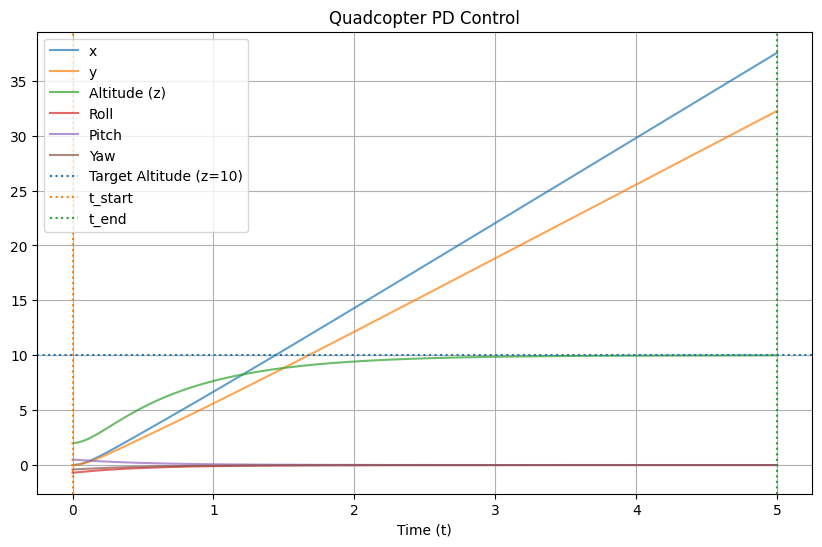

In [4]:
sol = run_simulation(t_span, initial_state, target_z, dt=0.02)
t_start, t_end = sol.t_span
print(f"Testing the sol object: t_span={sol.t_span}, dt={sol.dt}, n_steps={sol.n_steps}")
print(f"Testing the sol object: target_z = {sol.target_z}")

vars = ['X', 'Y', 'Z', 'Roll', 'Pitch', 'Yaw']
hlines = [(target_z, 'Target Altitude (z=10)')]
vlines = [(t_start, 't_start'), (t_end, 't_end')]

plot_simulation(sol, vars=vars, hlines=hlines, vlines=vlines, figsize=(10,6))

* As we see, the controller was able to drive our drone to the
  desired height z=10.0 (in less than 5 seconds).

* There is a question if this state is stable?
  Would the drone stay at this height for the next 120 seconds?
  What about the `x` and `y` coordinates? Are they stable too?
  These factors should test how good is our controller function.

* We can extend the value of `t_end` to 125 seconds, for example,
  and see what happens to the `(x,y,z)` values in
  the `(0,125)` time span.

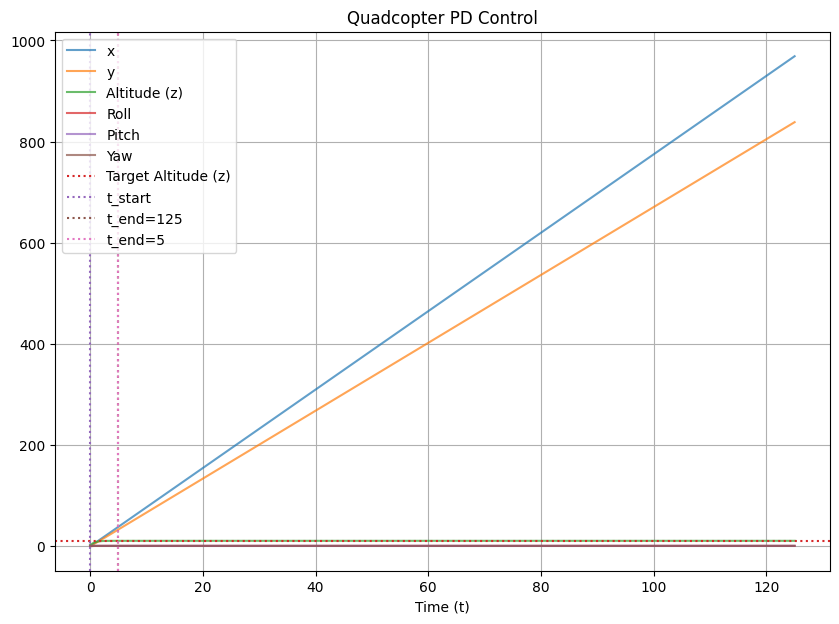

In [5]:
t_end2 = 125
t_span2 = (t_start, t_end2)
sol2 = run_simulation(t_span2, initial_state, target_z, dt=0.02)

vars = ['X', 'Y', 'Z', 'Roll', 'Pitch', 'Yaw']
hlines = [(target_z, 'Target Altitude (z)')]
vlines = [(t_start, 't_start'), (t_end, 't_end=125'), (5, 't_end=5')]

plot_simulation(sol2, vars=vars, hlines=hlines, vlines=vlines, figsize=(10,7))

* We can vaguely see that the `z` values are "stuck" around `z=10.0` (more or less some epsilon error).
  However, the `x` and `y` coordinates have drifted far away from their base (`x=y=0`)!
  Almost 1000 meters from their base!
* The probable explanation for this phenomenon is that the drone starts with a tilted
  roll, pitch, and yaw angles (`phi`, `theta`, `psi`) which also
  drives the drone at the `xy` directions and it keeps drifting
  in about 6 to 8 meters per second.
* Lets draw the graphs of `phi`, `theta`, and `psi` over our initial time span, and see
  how they behave?

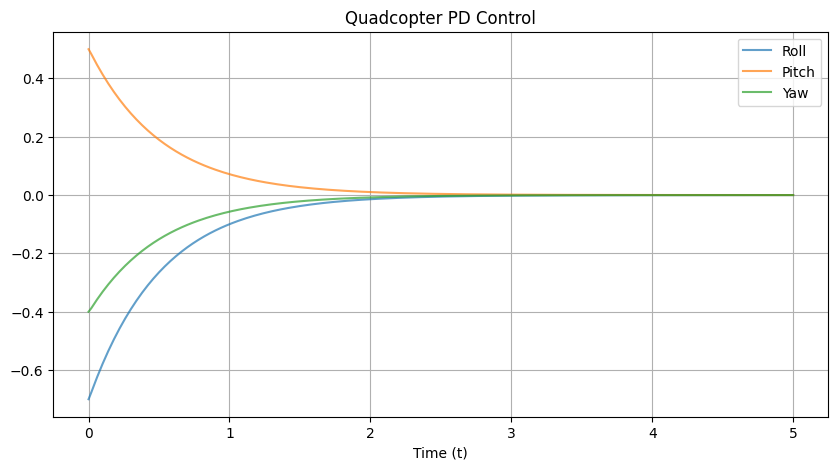

In [6]:
sol = run_simulation(t_span, initial_state, target_z, dt=0.02)
vars = ['Roll', 'Pitch', 'Yaw']
plot_simulation(sol, vars=vars, figsize=(10,5))

* We see that the drone's roll, pitch, and yaw start at significant
  non-zero values (-0.7, 0.5, -0.4) but quickly decrease toward zero after `t=1.5`.
  So around the time `t=2.5`, the drone should reach a horizontal state.
  But is it hovering or continues to drift?
* Well, between time `t=0` to `t=2.5`, the drone has accumulated some speed and acceleration,
  so it is expected to drift some more in the `x` and `y` directions.
* To check this hypothesis, lets draw the graphs of the coordinates speeds `(vx,vy,vz)`:

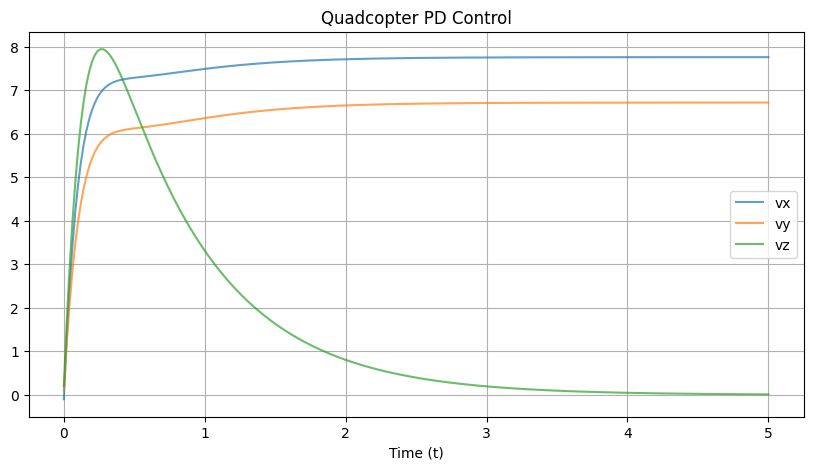

In [7]:
vars = ['VX', 'VY', 'VZ']
plot_simulation(sol, vars=vars, figsize=(10,5))

* We see that the drone's `x` coordinates has a speed `vx` around 8 meters per second
  for almost all the full time span, and the `y` coordinate travels at speed `vy>6`.
  So it is expected that the `(x,y)` coordinates will continue drifting along the
  extended time span `(5,125)`, as we saw in the previous graph.

* On the other hand, the speed of the `z` coordinate is
  quickly decreasing to zero, and about the time `t=5`
  it reaches zero speed, which means that it is in complete
  rest (as it reaches the target `z=10`).

* But of course, we cannot rely on these graphs as a proof for the $z=10.0 \pm \varepsilon$ stability
  across the `(5,125)` time span! We need to compute the exact range of `z`
  in this range and check each value.
  This will be the challenge of the first task.

* The harder challenge will be to design a better controller function which will
  keep the drone as close as possible to its `x=y=0` base within minimum time and energy cost.

## **TASK 1**
* Prove that that the drone maintains a stable height `z=10.0`
  (within `epsilon` error bounds) for the next 120 seconds.
* You need to write Python code for generating the $(x,y,z)$ data from
  `t=t_end` to `t=t_end+120`, and show that all the $z$ values
  satisfy $10-\varepsilon \leq z \leq 10+\varepsilon$.

* What happens to the roll, pitch, and yaw values? Did they drop below `epsilon`?
  Is the drone at a horizontal state after `t_end`, for at least 120 seconds?
  Prove your answer by code.

### **WRITE YOUR CODE IN THE FOLLOWING CODE CELL.**

In [ ]:
# STUDENT CODE CELL 1 (DO NOT ERASE OR CHANGE THIS LINE!)
# WRITE YOUR CODE HERE
# You will need to check 6 Numpy arrays for x, y, z and phi, theta, psi
# and check if they are close to the stable values within epsilon = 0.01
# The desired values for (x,y,z) are (0,0,10)
# and for (phi, theta, psi) are (0,0,0).
#
#
#

## **TASK 2**
* However, as we saw in the last graph, the drone has drifted
  far away from its earth frame base ($x=0$, $y=0$)!
  * Almost 40 meters from its $x=0$ base, in the first 5 seconds, and 840 meters after 125 meters.
  * More than 30 meters from its $y=0$ base in 5 seconds, and almost 1000 meters after 125 seconds.
  In most cases this drift is not desired. When we want to elevate the drone to some height,
  we usually want it to stay close to its $(x,y)$ position and just raise its $z$.

* This task will bear most of the credit for this project (~70%)!

* The major challenge is to write a better `controller` and `physics_dynamics`
  functions for ensuring that our drone stays (stable) in his base earth frame
  coordinates $x=0$, $y=0$ too!

### **WRITE YOUR CODE IN THE FOLLOWING CODE CELL.**
* The code in the following cell should not change except in the places
  where your asked to fill the missing code.
* Do not add any new functions or variables!
* Just fill the missing code lines where its explicitly asked.
  * The `controller` function should not be longer than 30 lines!
    Where average line length is 80 characters, not counting comments.
  * The `physics_dynamics` function should have maximum 15 lines.
  * The `run_simulation` function should stay almost the same as above,
    except for a few more arguments, and not more than additional 5 lines of code.
    * The last two plot functions should be very short, and should use the above `plot_simulation` function.
* This should constitute your solution to TASK 2.

In [ ]:
# STUDENT CODE CELL 2 (DO NOT ERASE OR CHANGE THIS LINE!)
import numpy as np
import random
from numpy import sin, cos, linspace
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from itertools import cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_cycle = cycle(colors)

# Physical Constants
g = 9.81    # gravity constant
m = 1.0     # quadcopter mass
Ixx = 0.01  # Moments of Inertia (I is a 3x3 diagonal matrix)
Iyy = 0.01
Izz = 0.02
L = 0.25    # Arm length
k = 1e-3    # Lift constant
b = 1e-4    # Drag constant

# PID Gains
Kp_x, Kd_x = # FILL TWO VALUES HERE
Kp_y, Kd_y = # FILL TWO VALUES HERE
Kp_z, Kd_z = # FILL TWO VALUES HERE
Kp_att, Kd_att = 10.1, 5.2

# Desired States
target_x = 0.0
target_y = 0.0
target_z = 10.0

t_start = 0  # Simulation start time in seconds
# Simulation time end time in seconds.
# You need to find the shortest possible value you can!
t_end = "FILL YOUR VALUE HERE"
t_span = (t_start, t_end)  # Simulation time span
dt = 0.02  # Discrete Time Step
x, y, z = (0, 0, 2.0)  # Initial (x,y,z) position in earth frame
vx, vy, vz = (-0.1, 0.1, 0.2)  # Initial velocity in earth frame
phi, theta, psi = (-0.7, 0.5, -0.4)  # Initial roll, pitch, and yaw angles
p, q, r = 0.01, 0.02, 0.03 # Initial body rotation rates
target_z = 10.0 # Target z coordinate (height) we want to reach
initial_state = (x, y, z, vx, vy, vz, phi, theta, psi, p, q, r)

def controller(state, target_z):
    # WRITE YOUR CODE HERE
    print("not implemented yet!")

def physics_dynamics(t, state, target_x, target_y, target_z):
    # WRITE YOUR CODE HERE
    print("not implemented yet!")

def run_simulation(t_span, initial_state, target_x, target_y, target_z, dt=0.02, dense_output=True):
    # WRITE YOUR CODE HERE
    print("not implemented yet!")

def plot_my_solution_xyz():
    # HERE YOU NEED TO WRITE THE CODE FOR COMPUTING THE VALUES
    # OF x,y,z, at time t, over your time span (t_start, t_end)
    # AND THEN PLOT THEIR GRAPHS USING THE plot_simulation FUNCTION ABOVE.
    print("not implemented yet!")

def plot_my_solution_phi_theta_psi():
    # HERE YOU NEED TO WRITE THE CODE FOR COMPUTING THE VALUES
    # OF phi, theta, psi, at time t, over your time span (t_start, t_end)
    # AND THEN PLOT THEIR GRAPHS USING THE plot_simulation FUNCTION ABOVE.
    print("not implemented yet!")

### **Directions and Grading Policy**
* The grade for TASK 2 will be determined by the following criteria:
  1. Shortest time `t_end` to reach the targets will win maximal grade.
  2. Stability for at least 2 minutes (120 seconds after `t_end`).
  3. Minimal route length (shortest route, not easy, but needed for a higher grade!)
  4. Minimal `xy-drift` within the time span `(t_start, t_end)`.
     * Within the `(t_start, t_end)` time span, the drone is expected to
       stay as close as possible to its base `(x,y) = (0,0)` coordinate.
     * Within the extended time span `(t_end, t_end+120)`, the drone `(x,y)` coordinates
       must remain within `epsilon=0.01` distance from the base `(0,0)`.
  5. The value of `z` in the time span `(t_end, t_end+120)`
     should be stable in the range $(9.99,10.01)$.
  6. The value of `z` in the time span `(t_start, t_end+120)`
     should not oscillate above the `z=10.2` limit.

* For that matter, the formula for the route length is:  

  $\qquad\displaystyle L = \int_{\text{t_start}}^{\text{t_end}} \sqrt{x'(t)^2 + y'(t)^2 + z'(t)^2}\,dt$  

  The grade for criterion 3 will be proportional to $1/L$.
  The smaller your $L$ is, the higher the grade is.

  **Exercise 2:**
  Write a Python function for computing the route length.  
  **Hint:** the derivatives $x'(t)$, $y'(t)$, $z'(t)$,
  are stored in `sol.y[3]`, `sol.y[4]`, `sol.y[5]`.
  The $dt$ is stored in `sol.dt`.
  You need to take the sum from `i=0` to `i=sol.n_steps`.  
  <small>(This exercise is for you, not part of the project)</small>

* Make sure not to add or change any of the Physics parameters
  (like the mass $m$, or gravitational constant, etc.)!
  * You will need to add two extra parameters
    ```python
    target_x = 0
    target_y = 0
    ```
    for trying to maintain the $(x,y)$ coordinates as close as possible to $(0,0)$,
    until they stay there permanently at time span `(t_end, t_end+120)` (within an `epsilon` bound of course).

  * You will also have to add and use the control parameters
    `Kp_x`, `Kp_y`, `Kd_z`, `Kd_x`, `Kd_y`, `Kd_z`
    which are needed to tune the drone controller function.
    Read about them in the above description and on the web.
    Learn their significance and role in tuning the drone controller.
    You may use Gemini on your Colab notebook to get more information and
    advice.

  * Intuition:
    * The `K_px`, `Kp_y`, `Kp_z` parameters provides the "springiness" - force proportional
      to distance.
    * The `K_dx`, `Kd_y`, `Kd_z` parameters provides the "friction" - force proportional to velocity.

  * You are allowed to play **only with the `Kp*` and `Kd*` control parameters, and `t_end` variables**
    * Namely: `Kp_x`, `Kp_y`, `Kp_z`, `Kd_x`, `Kd_y`, `Kd_z`, `t_end`.
    * The `K*` variables depend heavily on the drone's mass, size, motor strength,
      and other physical dynamics characteristics of the drone, which are irrelevant
      to our mathematical and programming objectives, so we will
      limit their values to the following typical ranges:
      * **`Kp_x, Kp_y, Kp_z`: 0.1 - 20.0**
      * **`Kd_x, Kd_y, Kd_z`: 0.01 - 15.0**

    * You may not change `Kp_att`, `Kd_att`. These are hardcoded values.

    * All other parameters that were assigned to your project should not change.

  * **Suggestion:**
    Start with a manual tuning (Heuristic Method) of these parameters and plot the state graphs.
    After that, try to search AI agents for methods to tune them more wisely.

  * And of course, you are not allowed to change the laws of Physics, as expressed
    in the `physics_dynamics` function.
    This function should stay essentially the same, except that you may add a `target_x`, `target_y`
    arguments to it (for passing these values to the controller).

  * As an illustration only, your simulation should look like in the following graph

    <IMG src="https://samyzaf.com/quad/figs/sol1.jpg" width=75% align="center"/>

  * Notice that the values of $x$ and $y$ may oscillate during your time span, but must be stabilized
    (for at least 120 seconds) when you reach `t=t_end`.
    The oscillation range sizes may effect the quality of the solution (and the project grade)
    if they are too large.
  * To add a more concrete illustration of the possible problems with this solution we have generated
    a video of the drone trajectory for this case.

In [8]:
display_video("https://samyzaf.com/quad/qc0.mp4")

* Notice the long and winding path (31.23 meters long!) that the drone does to make
  an 8 meters distance! This is highly inefficient!
  It also takes more than 10 seconds until the drone reaches the $(0,0,10)$ target,
  which is a long time.
* This poor trajectory proves that the `Kp/Kd` parameters we chose are far from optimal,
  or our controller function is not good enough.
  You must do better than that!
* Designing an effective controller function is one of the most challenging tasks in the
  field of drones, and the literature is full with many research papers which propose
  AI methods for it.
  These methods are beyond the scope of this introductory notebook,
  but we may attempt to present some interesting ones in more advanced projects.
* However, even within our limitations, you can find much better `Kp/Kd` parameters to minimize
  the drone path (and time!).

<IMG src="https://samyzaf.com/quad/figs/sep3.jpg" width=100% align="center"/>

## **BEST SUCCESS WITH YOUR WORK!**